# Medidas de Heterogeneidad

Índices para variables cualitativas: **Gini-Simpson**, **IQV** y **entropía de Shannon**, calculados sobre el dataset crudo y el procesado, con proporciones simples y ponderadas (`factor_expansion`). Las funciones están en `src/eda/medidas_heterogeneidad.py` y `src/eda/indices.py`.

## 1. Configuración

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from src.eda.medidas_heterogeneidad import COL_PESO, COLUMNAS, FUENTES, calcular_heterogeneidad
from src.visualization.graficas import aplicar_estilo, guardar_figura

aplicar_estilo()
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

## 2. Carga de datos

Las rutas vienen de `config/rutas.py`.

In [2]:
datos = {etiqueta: pl.read_csv(ruta) for etiqueta, ruta in FUENTES.items()}
for etiqueta, df in datos.items():
    print(f"{etiqueta:10s} {df.shape}")

crudo      (110127, 24)
procesado  (105753, 25)


## 3. Cálculo (crudo y procesado, simple y ponderado)

In [3]:
resultados = []
for etiqueta, df in datos.items():
    for peso, nombre_peso in [(None, "simple"), (COL_PESO, "ponderada")]:
        resultados.append(
            calcular_heterogeneidad(df, COLUMNAS, peso=peso).with_columns(
                pl.lit(etiqueta).alias("dataset"),
                pl.lit(nombre_peso).alias("proporciones"),
            )
        )
res = pl.concat(resultados)
res_pd = res.to_pandas()

with pl.Config(tbl_rows=-1):
    display(res.filter((pl.col("dataset") == "procesado") & (pl.col("proporciones") == "ponderada")))

variable,n,k,gini_simpson,gs_max,iqv,shannon_H,H_max,H_norm,dataset,proporciones
str,i64,i64,f64,f64,f64,f64,f64,f64,str,str
"""nom_entidad""",105753,32,0.945809,0.96875,0.976319,4.590937,5.0,0.918187,"""procesado""","""ponderada"""
"""nivel_escolaridad""",105753,6,0.673891,0.833333,0.808669,2.005634,2.584963,0.775885,"""procesado""","""ponderada"""
"""estado_civil_desc""",105753,6,0.758777,0.833333,0.910533,2.24682,2.584963,0.869189,"""procesado""","""ponderada"""
"""estrato_socioeconomico""",105753,4,0.652986,0.75,0.870649,1.741453,2.0,0.870727,"""procesado""","""ponderada"""
"""pareja_trabaja_desc""",105753,2,0.496014,0.5,0.992028,0.994242,1.0,0.994242,"""procesado""","""ponderada"""
"""dinero_propio_desc""",105753,2,0.498294,0.5,0.996588,0.997537,1.0,0.997537,"""procesado""","""ponderada"""
"""apoyo_gobierno_desc""",105753,2,0.225121,0.5,0.450242,0.555438,1.0,0.555438,"""procesado""","""ponderada"""
"""tiene_ahorros_desc""",105753,2,0.195616,0.5,0.391233,0.499561,1.0,0.499561,"""procesado""","""ponderada"""
"""propietaria_vivienda_desc""",105753,2,0.446755,0.5,0.893509,0.921758,1.0,0.921758,"""procesado""","""ponderada"""


## 4. Gráficas

El IQV y H/H_max van de 0 (una sola categoría concentra todo) a 1 (categorías balanceadas), por eso se pueden comparar entre variables con distinto número de categorías.

### 4.1 Crudo vs procesado (IQV, proporciones simples)

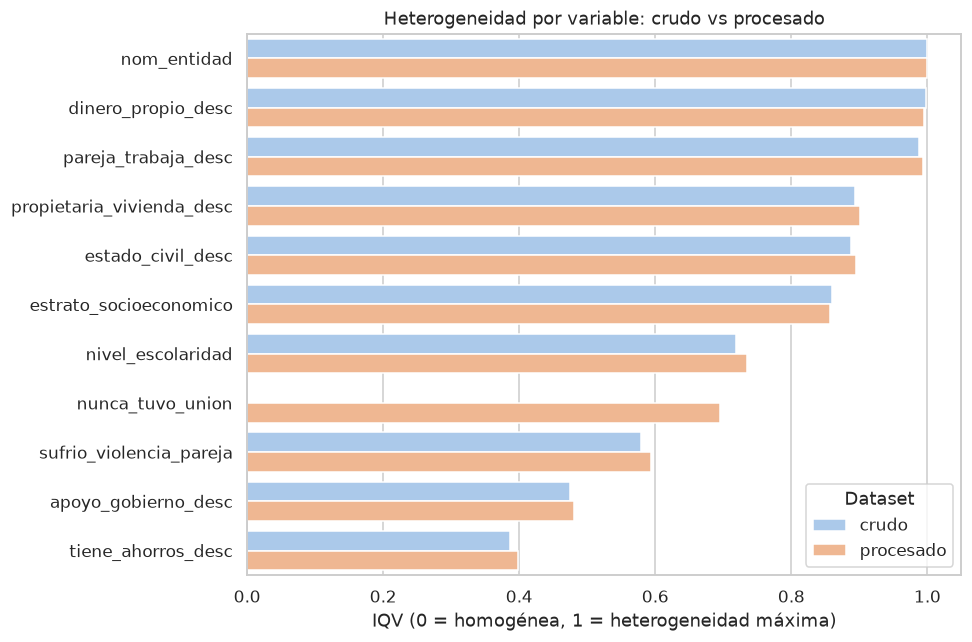

In [4]:
orden = (
    res_pd[(res_pd.dataset == "procesado") & (res_pd.proporciones == "simple")]
    .sort_values("iqv", ascending=False)["variable"].tolist()
)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=res_pd[res_pd.proporciones == "simple"], y="variable", x="iqv", hue="dataset", order=orden, ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel("IQV (0 = homogénea, 1 = heterogeneidad máxima)")
ax.set_ylabel("")
ax.set_title("Heterogeneidad por variable: crudo vs procesado")
ax.legend(title="Dataset", loc="lower right")
fig.tight_layout()
guardar_figura(fig, "het_crudo_vs_procesado")
plt.show()

### 4.2 Proporciones simples vs ponderadas (procesado)

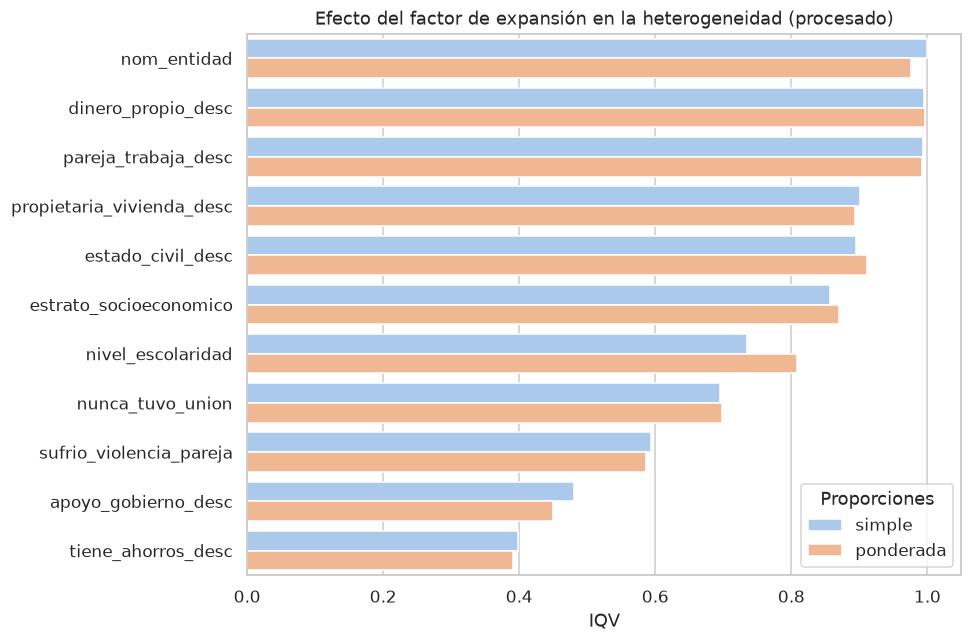

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=res_pd[res_pd.dataset == "procesado"], y="variable", x="iqv", hue="proporciones", order=orden, ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel("IQV")
ax.set_ylabel("")
ax.set_title("Efecto del factor de expansión en la heterogeneidad (procesado)")
ax.legend(title="Proporciones", loc="lower right")
fig.tight_layout()
guardar_figura(fig, "het_simple_vs_ponderada")
plt.show()

### 4.3 IQV vs entropía normalizada (procesado, ponderado)

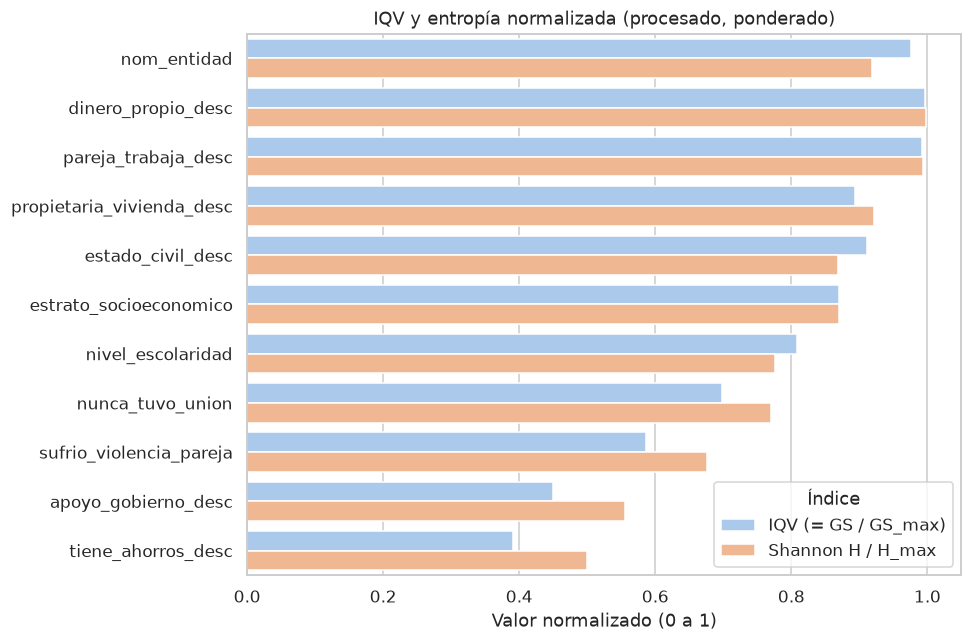

In [6]:
datos_indices = (
    res_pd[(res_pd.dataset == "procesado") & (res_pd.proporciones == "ponderada")]
    .melt(id_vars="variable", value_vars=["iqv", "H_norm"], var_name="indice", value_name="valor")
)
datos_indices["indice"] = datos_indices["indice"].map({"iqv": "IQV (= GS / GS_max)", "H_norm": "Shannon H / H_max"})
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=datos_indices, y="variable", x="valor", hue="indice", order=orden, ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Valor normalizado (0 a 1)")
ax.set_ylabel("")
ax.set_title("IQV y entropía normalizada (procesado, ponderado)")
ax.legend(title="Índice", loc="lower right")
fig.tight_layout()
guardar_figura(fig, "het_iqv_vs_entropia")
plt.show()

### 4.4 Mapa de calor de todos los índices (procesado, ponderado)

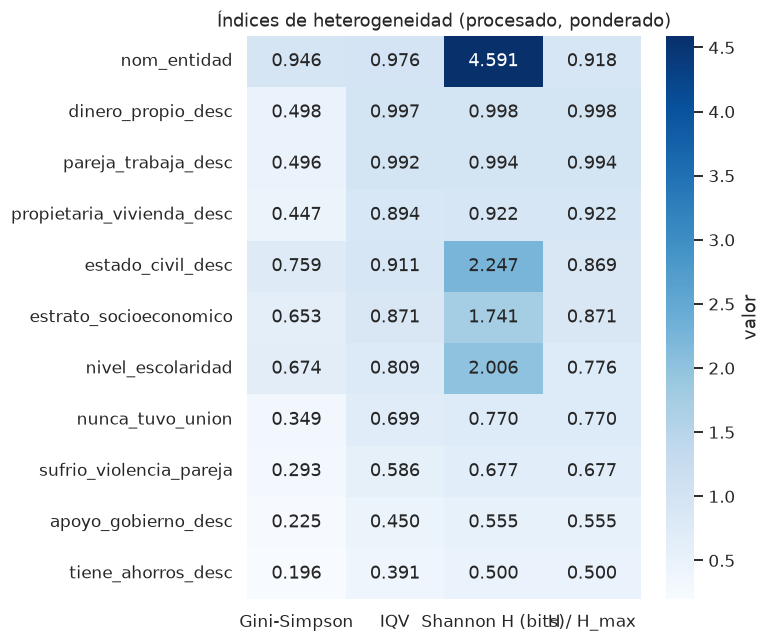

In [7]:
mapa = (
    res_pd[(res_pd.dataset == "procesado") & (res_pd.proporciones == "ponderada")]
    .set_index("variable")
    .loc[orden, ["gini_simpson", "iqv", "shannon_H", "H_norm"]]
)
mapa.columns = ["Gini-Simpson", "IQV", "Shannon H (bits)", "H / H_max"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(mapa, annot=True, fmt=".3f", cmap="Blues", cbar_kws={"label": "valor"}, ax=ax)
ax.set_ylabel("")
ax.set_title("Índices de heterogeneidad (procesado, ponderado)")
fig.tight_layout()
guardar_figura(fig, "het_mapa_calor")
plt.show()

## 5. Interpretación

- **Más heterogéneas**: las binarias balanceadas (dinero propio, IQV 0.997; pareja trabaja, 0.992) y, entre las de más categorías, el estado civil (IQV 0.911).
- **Menos heterogéneas**: tiene ahorros (0.391) y apoyo de gobierno (0.450), donde cerca del 89 % y 87 % responde «no»; y sufrió violencia de pareja (0.586), con 17.8 % de casos ponderados.
- **IQV vs entropía**: ordenan las variables casi igual; la entropía normalizada penaliza menos a las variables con una categoría dominante.
- **Ponderar**: la entidad federativa baja de IQV 1.00 a 0.976 porque la muestra tiene un tamaño parecido por entidad, mientras que la población no.